In [1]:
import re
import json
import nltk
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from collections import Counter
from datasets import load_dataset
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
 
# FIX: Set seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
 
# Download NLTK resources (run once)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_PATH = '/content/drive/MyDrive/sentiment_project/'
os.makedirs(SAVE_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
data = load_dataset("tweet_eval", "sentiment")
 
print(f"Train:      {len(data['train'])} samples")
print(f"Validation: {len(data['validation'])} samples")
print(f"Test:       {len(data['test'])} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train:      45615 samples
Validation: 2000 samples
Test:       12284 samples


In [6]:
print("\n=== Sample Tweet ===")
print(f"Text:  {data['train'][0]['text']}")
print(f"Label: {data['train'][0]['label']}")
print(f"\nRaw label counts: {Counter(data['train']['label'])}")


=== Sample Tweet ===
Text:  "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Label: 2

Raw label counts: Counter({1: 20673, 2: 17849, 0: 7093})


In [7]:
train_df = pd.DataFrame(data['train'])
test_df  = pd.DataFrame(data['test'])
val_df   = pd.DataFrame(data['validation'])
 
label_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
 
print("=== Dataset Statistics ===")
print(f"Total tweets: {len(train_df) + len(val_df) + len(test_df)}")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
# Label distribution
label_counts = train_df['label'].value_counts().sort_index()
print("\n=== Label Distribution (Train) ===")
for idx, count in label_counts.items():
    print(f"  {label_mapping[idx]}: {count} ({count / len(train_df) * 100:.1f}%)")
 
# Text length features
train_df['text_length'] = train_df['text'].apply(len)
train_df['word_count']  = train_df['text'].apply(lambda x: len(x.split()))
 
print("\n=== Text Length Statistics (Train) ===")
print(f"  Avg characters: {train_df['text_length'].mean():.1f}")
print(f"  Avg words:      {train_df['word_count'].mean():.1f}")
print(f"  Max words:      {train_df['word_count'].max()}")

=== Dataset Statistics ===
Total tweets: 59899
Train: 45615 | Val: 2000 | Test: 12284

=== Label Distribution (Train) ===
  Negative: 7093 (15.5%)
  Neutral: 20673 (45.3%)
  Positive: 17849 (39.1%)

=== Text Length Statistics (Train) ===
  Avg characters: 106.9
  Avg words:      19.2
  Max words:      35


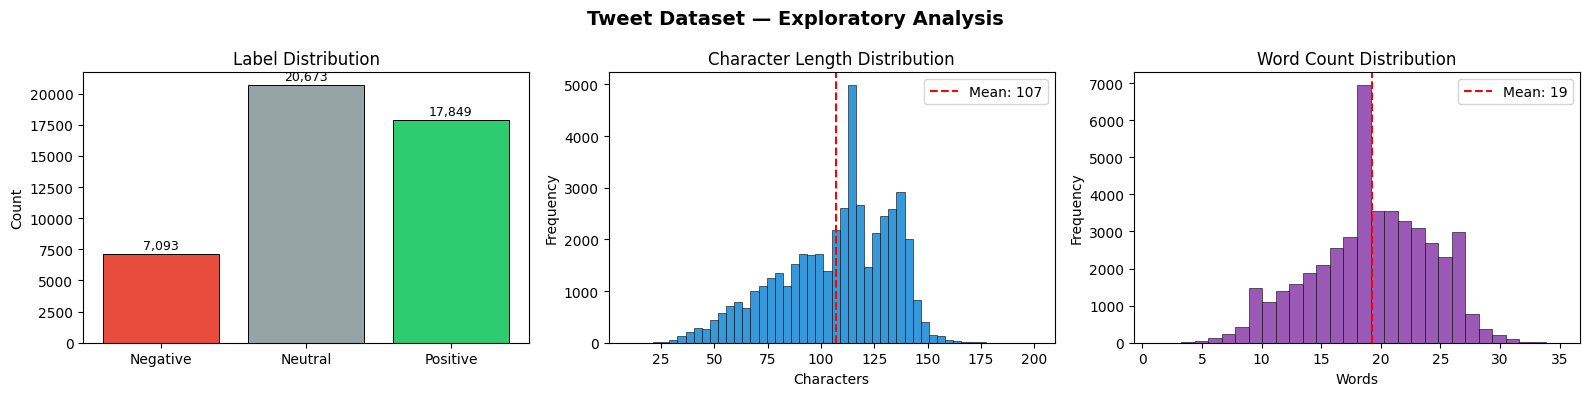

In [8]:
COLORS = {'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#2ecc71'}
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Tweet Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')

# 1. Label distribution with colors and value labels
bars = axes[0].bar(
    label_mapping.values(),
    label_counts.values,
    color=[COLORS[l] for l in label_mapping.values()],
    edgecolor='black', linewidth=0.7
)
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )
 
# 2. Character length distribution
axes[1].hist(train_df['text_length'], bins=50, color='#3498db', edgecolor='black', linewidth=0.4)
axes[1].set_title('Character Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')
axes[1].axvline(train_df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['text_length'].mean():.0f}")
axes[1].legend()
 
# 3. Word count distribution
axes[2].hist(train_df['word_count'], bins=30, color='#9b59b6', edgecolor='black', linewidth=0.4)
axes[2].set_title('Word Count Distribution')
axes[2].set_xlabel('Words')
axes[2].set_ylabel('Frequency')
axes[2].axvline(train_df['word_count'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['word_count'].mean():.0f}")
axes[2].legend()
 
plt.tight_layout()
plt.show()

In [9]:
class TweetPreprocessor:
    def __init__(self):
        # FIX: Removed strip_handles=True from tokenizer since we handle
        # mentions ourselves with <MENTION> tag below (avoids double handling)
        self.tokenizer = TweetTokenizer(
            preserve_case=False,   # lowercase
            reduce_len=True,       # gooooood -> goood
            strip_handles=False,   # we handle mentions manually with regex
        )
        self.stop_words = set(stopwords.words('english'))
 
    def preprocess(self, text: str, remove_stopwords: bool = True) -> str:
        """
        Clean and normalize a raw tweet.
 
        Steps:
            1. Lowercase
            2. Replace URLs with <URL> token
            3. Remove HTML tags
            4. Replace @mentions with <MENTION> token
            5. Fix repeated characters (coooool -> cool)
            6. Tokenize with TweetTokenizer
            7. Optionally remove stopwords  ← FIX: now actually applied
        """
        # 1. Lowercase
        text = text.lower()
 
        # 2. Replace URLs
        text = re.sub(r'https?://\S+|www\.\S+', '<url>', text)
 
        # 3. Remove HTML tags
        text = re.sub(r'<[^>]+>', '', text)
 
        # 4. Replace @mentions with token
        text = re.sub(r'@\w+', '<mention>', text)
 
        # 5. Fix repeated characters: coooool -> cool (max 2 repeats)
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)
 
        # 6. Tokenize
        tokens = self.tokenizer.tokenize(text)
 
        # 7. FIX: Actually remove stopwords when requested
        if remove_stopwords:
            tokens = [t for t in tokens if t not in self.stop_words]
 
        return ' '.join(tokens)

In [10]:
preprocessor = TweetPreprocessor()
 
sample_tweets = [
    "OMG this is AMAZING!!! 😍 #bestdayever https://example.com",
    "@user I'm so sad about this :( u know what i mean?",
    "RT: Check out this cool thing! #technology",
    "Looooove this product!!!! It's the BEST ever!!!",
]
 
print("=== Preprocessing Examples ===")
for tweet in sample_tweets:
    cleaned = preprocessor.preprocess(tweet)
    print(f"  Original : {tweet}")
    print(f"  Cleaned  : {cleaned}\n")

=== Preprocessing Examples ===
  Original : OMG this is AMAZING!!! 😍 #bestdayever https://example.com
  Cleaned  : omg amazing ! ! 😍 #bestdayever

  Original : @user I'm so sad about this :( u know what i mean?
  Cleaned  : <mention> sad :( u know mean ?

  Original : RT: Check out this cool thing! #technology
  Cleaned  : rt : check cool thing ! #technology

  Original : Looooove this product!!!! It's the BEST ever!!!
  Cleaned  : loove product ! ! best ever ! !



In [11]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, word2idx=None, max_length=50, min_freq=3, max_vocab_size=30000):
        """
        Args:
            texts:          List of preprocessed tweet strings
            labels:         List of integer labels (0=Negative, 1=Neutral, 2=Positive)
            word2idx:       Vocabulary dict (if None, built from texts)
            max_length:     Truncate sequences longer than this
            min_freq:       Minimum word frequency to include in vocab  (FIX: raised to 3)
            max_vocab_size: Hard cap on vocabulary size                  (FIX: added cap)
        """
        self.texts      = texts
        self.labels     = labels
        self.max_length = max_length
 
        if word2idx is None:
            self.word2idx = self._build_vocab(texts, min_freq, max_vocab_size)
        else:
            self.word2idx = word2idx
 
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
 
    def _build_vocab(self, texts, min_freq=3, max_vocab_size=30000):
        """Build vocabulary with frequency threshold and size cap."""
        counter = Counter()
        for text in texts:
            counter.update(text.split())
 
        # Special tokens always included
        special_tokens = ['<PAD>', '<UNK>', '<START>', '<END>']
 
        # Filter by frequency, sort by most common, cap size
        filtered = [
            word for word, freq in counter.most_common()
            if freq >= min_freq
        ][:max_vocab_size - len(special_tokens)]
 
        vocab = special_tokens + filtered
        print(f"  Vocab stats: {len(counter)} unique tokens → {len(vocab)} after filtering (min_freq={min_freq})")
        return {word: idx for idx, word in enumerate(vocab)}
 
    def __len__(self):
        return len(self.texts)
 
    def __getitem__(self, idx):
        text  = self.texts[idx]
        label = self.labels[idx]
 
        tokens  = text.split()[:self.max_length]
        tokens  = ['<START>'] + tokens + ['<END>']
        indices = [self.word2idx.get(t, self.word2idx['<UNK>']) for t in tokens]
 
        return {
            'text':    text,
            'indices': torch.tensor(indices, dtype=torch.long),
            'label':   torch.tensor(label,   dtype=torch.long),
            'length':  len(indices),
        }
 
 
def collate_fn(batch):
    """Pad variable-length sequences in a batch to the same length."""
    return {
        'texts':   [item['text'] for item in batch],
        'indices': pad_sequence(
            [item['indices'] for item in batch],
            batch_first=True,
            padding_value=0   # index of <PAD>
        ),
        'labels':  torch.stack([item['label']  for item in batch]),
        'lengths': torch.tensor([item['length'] for item in batch]),
    }

In [12]:
preprocessor = TweetPreprocessor()
 
print("Preprocessing datasets...")
train_df['preprocessed_text'] = train_df['text'].apply(preprocessor.preprocess)
val_df['preprocessed_text']   = val_df['text'].apply(preprocessor.preprocess)
test_df['preprocessed_text']  = test_df['text'].apply(preprocessor.preprocess)
 
print("Done.")
print(f"Example → Original:     {train_df['text'].iloc[0]}")
print(f"Example → Preprocessed: {train_df['preprocessed_text'].iloc[0]}")

Preprocessing datasets...
Done.
Example → Original:     "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Example → Preprocessed: " qt <mention> original draft 7th book , remus lupin survived battle hogwarts . #happybirthdayremuslupin "


In [14]:
print("\nBuilding vocabulary from training set...")
train_dataset = TweetDataset(
    train_df['preprocessed_text'].tolist(),
    train_df['label'].tolist()
)
 
# Val & Test share the training vocabulary (correct practice)
val_dataset = TweetDataset(
    val_df['preprocessed_text'].tolist(),
    val_df['label'].tolist(),
    word2idx=train_dataset.word2idx
)
test_dataset = TweetDataset(
    test_df['preprocessed_text'].tolist(),
    test_df['label'].tolist(),
    word2idx=train_dataset.word2idx
)
 
print(f"\nFinal vocabulary size: {len(train_dataset.word2idx)}")
 
# Save vocabulary for reuse (no need to rebuild next run)
with open('vocab.json', 'w') as f:
    json.dump(train_dataset.word2idx, f)
print("Vocabulary saved to vocab.json")
 
# DataLoaders
BATCH_SIZE = 32
 
# FIX: Pass generator with seed to shuffle for reproducibility
g = torch.Generator()
g.manual_seed(SEED)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, generator=g)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
 
print(f"\nTraining batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")


Building vocabulary from training set...
  Vocab stats: 48583 unique tokens → 14548 after filtering (min_freq=3)

Final vocabulary size: 14548
Vocabulary saved to vocab.json

Training batches:   1426
Validation batches: 63
Test batches:       384


In [15]:
for batch in train_loader:
    print("\n=== Example Batch ===")
    print(f"  Texts (first 2):  {batch['texts'][:2]}")
    print(f"  Indices shape:    {batch['indices'].shape}")
    print(f"  Labels shape:     {batch['labels'].shape}")
    print(f"  Lengths shape:    {batch['lengths'].shape}")
    print(f"  Label sample:     {batch['labels'][:8].tolist()}")
    break
 
print("\nAll done! Pipeline is ready for model training.")


=== Example Batch ===
  Texts (first 2):  ['weird day <mention> 1st - round leader dustin johnson 1 thru 11 falling board . <mention> golf_com', 'call tim tebow 4th quarter .']
  Indices shape:    torch.Size([32, 20])
  Labels shape:     torch.Size([32])
  Lengths shape:    torch.Size([32])
  Label sample:     [1, 1, 2, 1, 2, 1, 2, 1]

All done! Pipeline is ready for model training.


In [16]:
import json

with open(SAVE_PATH + 'vocab.json', 'w') as f:
    json.dump(train_dataset.word2idx, f)

train_df.to_csv(SAVE_PATH + 'train_preprocessed.csv', index=False)
val_df.to_csv(SAVE_PATH + 'val_preprocessed.csv', index=False)
test_df.to_csv(SAVE_PATH + 'test_preprocessed.csv', index=False)

print("Saved to Google Drive")

Saved to Google Drive
